**What this notebook does:**
1. Cleans up the datasets for data visualization.

2. Concatinates categories together that are redunadant for more acurate comparison scores.

3. Creates an 'opportunity_score' for gaging how good a city will be for a new company to locate in.


2. Creates a 'competition_score', so you can compare a company to its same cateogries within the same geographical area.
3. Creates an 'category_relative_score', so you can compare the company to its category across the state
4. Creats a 'standardized_city_rating' that is a z-score of the average rating in compairison to the area in which the company is located.
3. Creates a 'CI_for_avg_rating' for the probable average ratings a company could have.
4. Creates 2 datasets that can be used with these new columns of different sizes on big and one small for data visualization ready for Tableau visualizaiton.


**This code is an example for Washington although the data frames are labeled "Texas".**

**Step 1:** clean datasets before merging and feature engineering, so Tableau is displayed without outliers and NULL data.

In [297]:
import numpy as np
from sklearn.neighbors import BallTree
import pandas as pd
import numpy as np
import gzip
import json

pd.set_option('display.max_columns', None)

def parse(path):
  g = open('Data/' + path, 'r')
  for l in g:
    yield json.loads(l)

def parse_first_n(path, n=10000):
    g = open('Data/' + path, 'r')
    for i, l in enumerate(g):
        if i >= n:
            break
        yield json.loads(l)

In [298]:

texas_reviews = pd.DataFrame(parse_first_n("review-Washington.json", n=1000000)) # is not cleaned yet
#add more or less reviews depending on how well tableu responds to the data.


In [299]:
texas_metadata = pd.DataFrame(parse('meta-Washington.json'))

In [300]:
texas_metadata.head()

,name,address,gmap_id,description,latitude,longitude,category,avg_rating,num_of_reviews,price,hours,MISC,state,relative_results,url
0,Vancouver (99th St Station),"Vancouver (99th St Station), Vancouver, WA 98665",0x5495ae7d3bf7d097:0xbcbc06152a3ccebc,None,45.690693,-122.663733,[Bus station],3.6,28,None,None,"{'Accessibility': ['Passenger loading area', '...",None,"[0x5495a4bd41784269:0xb04d0997ebbbf7c1, 0x5495...",https://www.google.com/maps/place//data=!4m2!3...
1,Green Mountain Mobile Ranch,"Green Mountain Mobile Ranch, 21209 NE 58th St,...",0x5495ba6a9677196b:0xa46cbab362492a85,None,45.663385,-122.454082,[Mobile home park],3.3,8,None,None,None,None,"[0x5495b02498a76307:0xe868c048706b0155, 0x5495...",https://www.google.com/maps/place//data=!4m2!3...
2,Sherwood Adult Family Home,"Sherwood Adult Family Home, 11017 NE Sherwood ...",0x5495ae0c320b8b1d:0xf3a26508566231ab,None,45.701703,-122.636181,[Retirement home],5.0,3,None,None,{'Accessibility': ['Wheelchair accessible entr...,None,"[0x5495affe3179702b:0x30ffaacb5efa35a1, 0x5495...",https://www.google.com/maps/place//data=!4m2!3...
3,Electric Vehicle Charging Station,"Electric Vehicle Charging Station, 4829 SW Bar...",0x5490414eb548468f:0x94cd1464233f4b0c,None,47.523139,-122.393244,[Electric vehicle charging station],3.2,5,None,"[[Thursday, Open 24 hours], [Friday, Open 24 h...",None,Open 24 hours,"[0x549040fed35690db:0xcb011043c981e1b, 0x54906...",https://www.google.com/maps/place//data=!4m2!3...
4,Electric Vehicle Charging Station,"Electric Vehicle Charging Station, 225 S Spoka...",0x5490402d689cd5f5:0xb0102b6e33fe1a36,None,47.571246,-122.328112,[Electric vehicle charging station],3.5,4,None,"[[Thursday, Open 24 hours], [Friday, Open 24 h...",None,Open 24 hours,None,https://www.google.com/maps/place//data=!4m2!3...


In [301]:
texas_reviews.head()

,user_id,name,time,rating,text,pics,resp,gmap_id
0,101193190259063567920,Ian Hampton,1627207184860,5.0,Drivers are helpful with directions or assista...,None,None,0x5495ae7d3bf7d097:0xbcbc06152a3ccebc
1,103093043835388050629,Casper Steele,1626907411534,2.0,Drivers say security has bathroom key. Securit...,None,None,0x5495ae7d3bf7d097:0xbcbc06152a3ccebc
2,111014066796803341223,Judy Maes,1613028426989,5.0,It's a CTRAN transit center with schedules to ...,None,None,0x5495ae7d3bf7d097:0xbcbc06152a3ccebc
3,112375894485126147782,Jengibre Caro,1590119768856,3.0,"Positives: usually clean, convenient location,...",None,None,0x5495ae7d3bf7d097:0xbcbc06152a3ccebc
4,111724423355988809570,Daniel Hernandez,1536710665852,5.0,Neat little Transit Center with lots of schedu...,None,None,0x5495ae7d3bf7d097:0xbcbc06152a3ccebc


In [302]:

category_reference_df = pd.read_csv('data/smaller_categories2.csv')
category_reference_df = category_reference_df.rename(columns = {'category':'small_group', 'subcategory': 'category_name'} )
category_reference_df

,industry,small_group,category_name
0,Agriculture & Natural Resources,Agricultural Services,agricultural
1,Agriculture & Natural Resources,Agricultural Services,agricultural association
2,Agriculture & Natural Resources,Agricultural Services,agricultural cooperative
3,Agriculture & Natural Resources,Agricultural Services,agricultural organization
4,Agriculture & Natural Resources,Agricultural Services,agricultural production
...,...,...,...
4269,Sports,Other Sports,table tennis facility
4270,Sports,Sports Facilities,american football field
4271,Sports,Sports Facilities,baseball field
4272,Sports,Sports Facilities,football field


In [303]:

# reshape a DataFrame from a wide format to a long format. => Convert the main category column to rows.
category_reference_df = category_reference_df.dropna()


In [304]:
# Clean the reference category 
category_reference_df['cateogry_name'] = (
    category_reference_df['category_name']
    .str.lower()
    .str.strip()
)



**Clean the data**

In [305]:
texas_reviews = texas_reviews.dropna(subset=['rating'])# Drop rows where 'rating' is NaN])

In [306]:
texas_metadata = texas_metadata.dropna(subset=['gmap_id', 'name']).drop_duplicates(subset=['gmap_id'], keep='first')



In [307]:
texas_metadata = texas_metadata[texas_metadata['state'] != 'Permanently closed']



Filter out lat and long outliers


(45.32, 49.2)

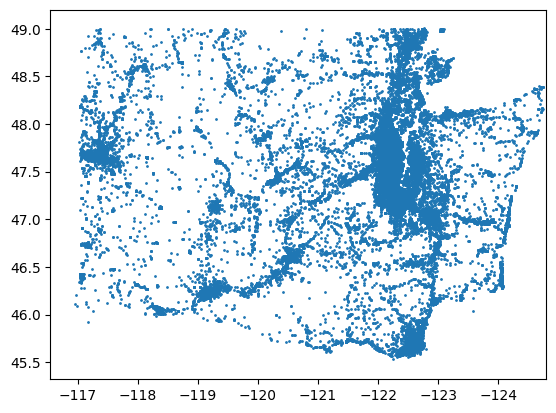

In [308]:
import matplotlib.pyplot as plt
plt.plot(texas_metadata['longitude'], texas_metadata['latitude'], 'o', markersize=1)
plt.xlim([-116.55, -124.8])
plt.ylim([45.32,49.2])

In [309]:
texas_metadata = texas_metadata[(texas_metadata['latitude'] >= 45.32) & (texas_metadata['latitude'] <= 49.2)
                            & (texas_metadata['longitude'] >= -124.8) & (texas_metadata['longitude'] <= -116.55)
]

In [310]:
texas_metadata.shape[0]

113478

**Add a city column to each company**

In [311]:
def standardize_rating_by_city(df):
    """
    Standardizes average ratings relative to each city's mean and standard deviation.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        DataFrame with 'avg_rating' and 'city' columns
        
    Returns:
    --------
    pandas.Series
        Z-scores (standardized ratings) for each row
    """
    # Calculate city-level statistics
    city_stats = df.groupby('city')['avg_rating'].agg(['mean', 'std'])
    
    # Map city statistics to each row
    df_with_stats = df.copy()
    df_with_stats['city_mean'] = df['city'].map(city_stats['mean'])
    df_with_stats['city_std'] = df['city'].map(city_stats['std']) #map is like a mini merge
    
    # Calculate z-score: (value - mean) / std
    # Handle cases where std is 0 (all ratings in city are the same)
    standardized = (df_with_stats['avg_rating'] - df_with_stats['city_mean']) / df_with_stats['city_std'].replace(0, 1)
    
    return standardized

# Apply the function to add standardized ratings


In [312]:
path = 'Data/simplemaps_uscities_basicv1.93/uscities.csv'

us_cities = pd.read_csv(path)



# Convert to radians


category_df = texas_metadata.copy()
#THIS WILL FIRST ADD A CITY COLUMN TO OUR METADATA SO WE CAN GROUP
cities_rad = np.radians(us_cities[['lat', 'lng']])
companies_rad = np.radians(category_df[['latitude', 'longitude']])

# Build BallTree
tree = BallTree(cities_rad, metric='haversine')

# Find nearest city for each company
distances, indices = tree.query(companies_rad, k=1)

# Assign city name
nearest_city_names = us_cities.iloc[indices.flatten()]['city'].reset_index(drop=True)

category_df = category_df.reset_index(drop=True)
category_df['city'] = nearest_city_names
#now has a city column on category_df which we can use groupby to attatch a new column for
category_df['demand'] = category_df.groupby('city')['gmap_id'].transform('count')
df_for_later = category_df.copy()
category_df['standardized_city_rating'] = standardize_rating_by_city(category_df)

#Extract all unique category labels from california_metadata
category_df = category_df.explode('category')
#Convert everything to lower case and remove blank space 
category_df['category'] = category_df['category'].str.lower().str.strip()






In [313]:
# Left merge category_df with category_reference_df to map subcategories to main categories
category_df = category_df.merge(
    category_reference_df,
    left_on='category',
    right_on='category_name',
    how='left'
)






In [314]:

category_df[['industry', 'small_group']] = (
    category_df[['industry', 'small_group']].fillna('Other')
)

In [315]:
category_df.head()

,name,address,gmap_id,description,latitude,longitude,category,avg_rating,num_of_reviews,price,hours,MISC,state,relative_results,url,city,demand,standardized_city_rating,industry,small_group,category_name,cateogry_name
0,Vancouver (99th St Station),"Vancouver (99th St Station), Vancouver, WA 98665",0x5495ae7d3bf7d097:0xbcbc06152a3ccebc,None,45.690693,-122.663733,bus station,3.6,28,None,None,"{'Accessibility': ['Passenger loading area', '...",None,"[0x5495a4bd41784269:0xb04d0997ebbbf7c1, 0x5495...",https://www.google.com/maps/place//data=!4m2!3...,Hazel Dell,716,-1.182399,Automotive & Transportation,Other Auto & Transport,bus station,bus station
1,Green Mountain Mobile Ranch,"Green Mountain Mobile Ranch, 21209 NE 58th St,...",0x5495ba6a9677196b:0xa46cbab362492a85,None,45.663385,-122.454082,mobile home park,3.3,8,None,None,None,None,"[0x5495b02498a76307:0xe868c048706b0155, 0x5495...",https://www.google.com/maps/place//data=!4m2!3...,Fern Prairie,48,-2.454389,"Arts, Entertainment & Recreation",Parks & Recreation,mobile home park,mobile home park
2,Sherwood Adult Family Home,"Sherwood Adult Family Home, 11017 NE Sherwood ...",0x5495ae0c320b8b1d:0xf3a26508566231ab,None,45.701703,-122.636181,retirement home,5.0,3,None,None,{'Accessibility': ['Wheelchair accessible entr...,None,"[0x5495affe3179702b:0x30ffaacb5efa35a1, 0x5495...",https://www.google.com/maps/place//data=!4m2!3...,Salmon Creek,305,1.225133,Real estate & construction,Other Real Estate & Construction,retirement home,retirement home
3,Electric Vehicle Charging Station,"Electric Vehicle Charging Station, 4829 SW Bar...",0x5490414eb548468f:0x94cd1464233f4b0c,None,47.523139,-122.393244,electric vehicle charging station,3.2,5,None,"[[Thursday, Open 24 hours], [Friday, Open 24 h...",None,Open 24 hours,"[0x549040fed35690db:0xcb011043c981e1b, 0x54906...",https://www.google.com/maps/place//data=!4m2!3...,White Center,862,-1.857797,Others,Other,electric vehicle charging station,electric vehicle charging station
4,Electric Vehicle Charging Station,"Electric Vehicle Charging Station, 225 S Spoka...",0x5490402d689cd5f5:0xb0102b6e33fe1a36,None,47.571246,-122.328112,electric vehicle charging station,3.5,4,None,"[[Thursday, Open 24 hours], [Friday, Open 24 h...",None,Open 24 hours,None,https://www.google.com/maps/place//data=!4m2!3...,Seattle,9575,-1.290509,Others,Other,electric vehicle charging station,electric vehicle charging station


In [316]:
match_rate = category_df['small_group'].notna().mean() * 100
print(f"Match rate: {match_rate:.2f}%")
category_df[category_df['small_group'].isna()]

Match rate: 100.00%


,name,address,gmap_id,description,latitude,longitude,category,avg_rating,num_of_reviews,price,hours,MISC,state,relative_results,url,city,demand,standardized_city_rating,industry,small_group,category_name,cateogry_name


**Everything matches so we are good to proceed**

In [317]:
category_df.drop(columns=['cateogry_name'], inplace=True)
#OPORTUNITY score needs to remain as is so that we can track niche oportunities.

In [318]:
category_stats = category_df.groupby('category')['avg_rating'].agg(['mean', 'std'])
small_category_stats = category_df.groupby('small_group')['avg_rating'].agg(['mean', 'std'])
# Map city statistics to each row
df_with_stats = category_df.copy()

df_with_stats['cat_mean'] = df_with_stats['category'].map(category_stats['mean'])
df_with_stats['cat_std'] = df_with_stats['category'].map(category_stats['std'])
df_with_stats['small_cat_mean'] = df_with_stats['small_group'].map(small_category_stats['mean'])
df_with_stats['small_cat_std'] = df_with_stats['small_group'].map(small_category_stats['std'])

# Calculate z-score: (value - mean) / std
# Handle cases where std is 0 (all ratings in city are the same)
category_df['Entire_category_score'] = (df_with_stats['avg_rating'] - df_with_stats['cat_mean']) / df_with_stats['cat_std'].replace(0, 1)
#this remains the same as the entire category is large enough to use niche categories


In [319]:
# # # #Remove tiny categories 
category_counts= category_df.get('category').value_counts()
small_category_counts = category_df.get('small_group').value_counts()


# Setting threshold for the category 
category_counts.describe()
small_category_counts.describe()
category_counts_threshold = 35 #median, we could alter this if there are too many categories for our deomo

#this only necessary for category_counts categories as they are much more niche

# Map category_count to each category in the df
category_df['category_count'] = category_df['category'].map(category_counts)
category_df['small_category_count'] = category_df['small_group'].map(small_category_counts)
# category_df = category_df[category_df.get('category_count') >= category_counts_threshold]
# category_df = category_df.sort_values(by='category_count', ascending=False)


**Aggregate to each category within each city**

In [320]:

# Calculate mean, std, and count for each category within each city
category_stats = category_df.groupby(["city", "category"])['avg_rating'].agg(['mean', 'std', 'count']).reset_index()
category_stats.columns = ['city', 'category', 'cc_mean', 'cc_std', 'cc_count'] 

small_category_stats = category_df.groupby(["city", "small_group"])['avg_rating'].agg(['mean', 'std', 'count']).reset_index()
small_category_stats.columns = ['scity', 'scategory', 'scc_mean', 'scc_std', 'scc_count'] 

 # rename columns for clarity
#use these for our average rating of category in the city column

In [321]:
category_stats
small_category_stats

,scity,scategory,scc_mean,scc_std,scc_count
0,Aberdeen,Accounting & Tax,3.100000,NaN,1
1,Aberdeen,Auto Body,4.300000,NaN,1
2,Aberdeen,Auto Repair,4.333333,0.152753,3
3,Aberdeen,Bakery & Dessert,4.350000,0.369685,4
4,Aberdeen,Bank & Credit Union,4.000000,0.264575,3
...,...,...,...,...,...
18864,Zillah,Pizza,3.900000,0.000000,2
18865,Zillah,Postal Services,3.800000,NaN,1
18866,Zillah,Restaurant,4.000000,0.555959,12
18867,Zillah,Salon & Spa,4.600000,0.000000,3


In [322]:

# Merge back into category data set (here category df is just the exploded metadata with city and category count)


mcategory_df = category_df.merge(category_stats, on=['city', 'category'], how='inner').merge(small_category_stats, left_on = ['city', 'small_group'], right_on = ['scity', 'scategory'], how= 'inner') #merge on both city and category
mcategory_df['cc_count'] = (
    mcategory_df.groupby(['city', 'category'])['gmap_id']
      .transform('nunique')
)
###########
# This does not need to change as we want oportuity score to remain niche
###########

mcategory_df
mcategory_df.drop(columns=[ 'category_count'])






,name,address,gmap_id,description,latitude,longitude,category,avg_rating,num_of_reviews,price,hours,MISC,state,relative_results,url,city,demand,standardized_city_rating,industry,small_group,category_name,Entire_category_score,small_category_count,cc_mean,cc_std,cc_count,scity,scategory,scc_mean,scc_std,scc_count
0,Vancouver (99th St Station),"Vancouver (99th St Station), Vancouver, WA 98665",0x5495ae7d3bf7d097:0xbcbc06152a3ccebc,None,45.690693,-122.663733,bus station,3.6,28,None,None,"{'Accessibility': ['Passenger loading area', '...",None,"[0x5495a4bd41784269:0xb04d0997ebbbf7c1, 0x5495...",https://www.google.com/maps/place//data=!4m2!3...,Hazel Dell,716,-1.182399,Automotive & Transportation,Other Auto & Transport,bus station,-0.563307,2250,3.600000,NaN,1,Hazel Dell,Other Auto & Transport,4.270000,0.661020,20
1,Green Mountain Mobile Ranch,"Green Mountain Mobile Ranch, 21209 NE 58th St,...",0x5495ba6a9677196b:0xa46cbab362492a85,None,45.663385,-122.454082,mobile home park,3.3,8,None,None,None,None,"[0x5495b02498a76307:0xe868c048706b0155, 0x5495...",https://www.google.com/maps/place//data=!4m2!3...,Fern Prairie,48,-2.454389,"Arts, Entertainment & Recreation",Parks & Recreation,mobile home park,-0.900687,4686,3.450000,0.212132,2,Fern Prairie,Parks & Recreation,3.450000,0.212132,2
2,Sherwood Adult Family Home,"Sherwood Adult Family Home, 11017 NE Sherwood ...",0x5495ae0c320b8b1d:0xf3a26508566231ab,None,45.701703,-122.636181,retirement home,5.0,3,None,None,{'Accessibility': ['Wheelchair accessible entr...,None,"[0x5495affe3179702b:0x30ffaacb5efa35a1, 0x5495...",https://www.google.com/maps/place//data=!4m2!3...,Salmon Creek,305,1.225133,Real estate & construction,Other Real Estate & Construction,retirement home,1.299248,606,5.000000,NaN,1,Salmon Creek,Other Real Estate & Construction,5.000000,NaN,1
3,Electric Vehicle Charging Station,"Electric Vehicle Charging Station, 4829 SW Bar...",0x5490414eb548468f:0x94cd1464233f4b0c,None,47.523139,-122.393244,electric vehicle charging station,3.2,5,None,"[[Thursday, Open 24 hours], [Friday, Open 24 h...",None,Open 24 hours,"[0x549040fed35690db:0xcb011043c981e1b, 0x54906...",https://www.google.com/maps/place//data=!4m2!3...,White Center,862,-1.857797,Others,Other,electric vehicle charging station,-0.751073,40975,3.066667,0.709460,3,White Center,Other,4.319157,0.615580,261
4,Electric Vehicle Charging Station,"Electric Vehicle Charging Station, 225 S Spoka...",0x5490402d689cd5f5:0xb0102b6e33fe1a36,None,47.571246,-122.328112,electric vehicle charging station,3.5,4,None,"[[Thursday, Open 24 hours], [Friday, Open 24 h...",None,Open 24 hours,None,https://www.google.com/maps/place//data=!4m2!3...,Seattle,9575,-1.290509,Others,Other,electric vehicle charging station,-0.443116,40975,3.193333,1.261783,15,Seattle,Other,4.348026,0.605984,3192
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
256176,Pharmaca,"Pharmaca, 4707 California Ave SW, Seattle, WA ...",0x549040f97ff0e48f:0x6c744157687fc407,Pharmacy stocking traditional health products ...,47.560912,-122.387184,organic drug store,4.5,38,None,"[[Wednesday, 9AM–7PM], [Thursday, 9AM–7PM], [F...","{'Service options': ['Curbside pickup', 'Deliv...",NaN,"[0x5490145744a22a99:0xa034b5ee8d669cbe, 0x5490...",https://www.google.com/maps/place//data=!4m2!3...,White Center,862,0.241686,Retail & Consumer Services,Other Retail,organic drug store,0.594228,46940,4.500000,NaN,1,White Center,Other Retail,4.338462,0.465740,338
256177,Pharmaca,"Pharmaca, 4707 California Ave SW, Seattle, WA ...",0x549040f97ff0e48f:0x6c744157687fc407,Pharmacy stocking traditional health products ...,47.560912,-122.387184,organic shop,4.5,38,None,"[[Wednesday, 9AM–7PM], [Thursday, 9AM–7PM], [F...","{'Service options': ['Curbside pickup', 'Deliv...",NaN,"[0x5490145744a22a99:0xa034b5ee8d669cbe, 0x5490...",https://www.google.com/maps/place//data=!4m2!3...,White Center,862,0.241686,Retail & Consumer Services,Other Retai

In [323]:
mcategory_df.columns #lets use cc_mean and keep it as a column 
#so we can do 5 - df['cc_mean'] to get our quality penalty


Index(['name', 'address', 'gmap_id', 'description', 'latitude', 'longitude',
       'category', 'avg_rating', 'num_of_reviews', 'price', 'hours', 'MISC',
       'state', 'relative_results', 'url', 'city', 'demand',
       'standardized_city_rating', 'industry', 'small_group', 'category_name',
       'Entire_category_score', 'category_count', 'small_category_count',
       'cc_mean', 'cc_std', 'cc_count', 'scity', 'scategory', 'scc_mean',
       'scc_std', 'scc_count'],
      dtype='object')

In [324]:

# competition score = normalized rating in local area relative to competition
# If less than 2 companies in the city-category combo, mark as insufficient data
mcategory_df['competition_score'] = mcategory_df.apply(
    lambda row: 
        (row['avg_rating'] - row['cc_mean']) / row['cc_std']
        if (row['cc_count'] >= 2 and row['cc_std'] != 0)
        else np.nan,
    axis=1
)

mcategory_df['broad_competition_score'] = mcategory_df.apply(
    lambda row: 
        (row['avg_rating'] - row['scc_mean']) / row['scc_std']
        if (row['scc_count'] >= 2 and row['scc_std'] != 0)
        else np.nan,
    axis=1
)



mcategory_df = mcategory_df.groupby('gmap_id').agg({
    'competition_score': 'mean',
    'broad_competition_score': 'mean',
    'standardized_city_rating': 'mean',
    'Entire_category_score': 'mean',
    'cc_mean': 'mean',
    'cc_count': 'mean', 
    'demand': 'first'
    
    #this gives us cc_mean as a col to use 'opportunity'
}).reset_index()

mcategory_df #The reason that the number dropped is becuase explode will create multiple rows and grouping by gmap_id will reduce that back


,gmap_id,competition_score,broad_competition_score,standardized_city_rating,Entire_category_score,cc_mean,cc_count,demand
0,0x0:0xb753ff108b8c71,-0.834391,-0.807530,-0.959434,-1.123453,3.853500,3.600000,630
1,0x1fb7f065b35a11c3:0x1166726ea38dac83,1.269465,1.271001,0.467646,1.119846,4.271149,23.333333,784
2,0x410755634e101ab5:0x864b7fcdf73f1f00,-0.301823,-0.151462,0.542073,-0.128831,4.678261,23.000000,1187
3,0x4107559100f39eed:0xf8e0bda433717a89,NaN,0.208621,-0.073568,-0.868383,4.100000,1.000000,168
4,0x41075594ab033ee3:0xa97f04d1f4651c97,NaN,0.914346,0.204131,0.596285,4.400000,1.000000,1187
...,...,...,...,...,...,...,...,...
113025,0x89e6353f0d4fdc7f:0x7df24240835916ab,0.501363,0.846636,0.873462,0.557724,4.623214,9.000000,1961
113026,0x8c0368a1aa9183db:0x4b51005706c4dc34,-0.371197,-0.093747,0.035161,0.436173,4.372500,5.000000,1187
113027,0x8f7d146e29c0aae5:0x7d272d7e34db44fd,NaN,0.910026,0.969212,1.306052,5.000000,1.000000,978
113028,0x8fdcae67c98856f1:0x59cd47f85080433e,0.603837,1.035864,1.054114,0.904699,4.855000,6.000000,1657


In [325]:
#We will merge all of this back into texas metadata with an inner merge to add the new z-score and CI columns for the Tableu dataset.

company_stats = (
    texas_reviews #first time using texas reviews, we should definetly do a left merge for CI, since limmited data n=1000000
        .groupby('gmap_id')['rating']
        .agg(['mean', 'std', 'count'])
        .reset_index()
)

def compute_ci(row):
    mean = row['mean']
    std = row['std']
    n = row['count']
    
    if n == 0:
        return None
    
    margin = 1.96 * (std / np.sqrt(n))
    return (mean - margin, mean + margin)

company_stats['CI'] = company_stats.apply(compute_ci, axis=1)

mtexas_metadata = texas_metadata.merge(
    company_stats[['gmap_id', 'CI']],
    on='gmap_id',
    how='inner'
)

# mcategory_df['CI']= mcategory_df['gmap_id'].apply(individual_company_rating_confidence_interval)






**<u>The list format of categories doesen't matter becuse the competition score already finds the competition relative to all of the companies categories, This score is the most important as it is more acurate at it takes into account multiple varibales rather than just one, calculates them separately and then avereges the scores.**



In [326]:


final_texas_metadata = texas_metadata.merge(mtexas_metadata[['gmap_id', 'CI']], on='gmap_id', how='left').merge(mcategory_df[['gmap_id', 'competition_score','broad_competition_score', 'standardized_city_rating', 'Entire_category_score', 'cc_count', 'demand', 'cc_mean']], on='gmap_id', how='left')
final_texas_metadata['competition_score'] = final_texas_metadata['competition_score'].fillna("not enough data")
final_texas_metadata['broad_competition_score'] = final_texas_metadata['broad_competition_score'].fillna("not enough data")
final_texas_metadata = final_texas_metadata.merge(df_for_later[['gmap_id','city']], on= 'gmap_id') #WTF IS WRONG
#shuold be > 409k
final_texas_metadata['category'] = final_texas_metadata['category'].apply(lambda x: tuple(x) if x is not None else None)

**BELOW ARE 2 FINAL DATASETS**

Small_... includes only the columns from the merge with the 1 million rows from meta and no NaN values. 

Big_... includes all the columns from meta and more NaN values.

In [327]:
small_test_final_texas_metadata = final_texas_metadata.dropna(subset=['CI'])
small_test_final_texas_metadata = small_test_final_texas_metadata[~small_test_final_texas_metadata['CI'].apply(lambda x: any(pd.isna(i) for i in x))]
small_test_final_texas_metadata['CI'] = small_test_final_texas_metadata['CI'].apply(lambda x: (x[0],5.0) if x[1] > 5.0 else (1.0, x[1]) if x[0] < 1.0 else x)
small_test_final_texas_metadata = small_test_final_texas_metadata.rename(columns={
    'CI': 'CI_for_avg_rating',
    'Entire_category_score': 'category_relative_score'
})

# Merge in city and category from category_df (which has the city/category mapping)






**Adjusting confidence intervals**

In [328]:
big_test_final_texas_metadata = final_texas_metadata.copy()

def clamp_ci(x): #this fucniton is only needed for big due to NaN handling
    # Skip NaN or non-tuples
    if not isinstance(x, (tuple, list)):
        return x
    
    lower, upper = x
    
    # Clamp values
    lower = max(1.0, lower)
    upper = min(5.0, upper)
    
    return (lower, upper)

big_test_final_texas_metadata['CI'] = (
    big_test_final_texas_metadata['CI'].apply(clamp_ci)
)

# Rename columns
big_test_final_texas_metadata = big_test_final_texas_metadata.rename(columns={
    'CI': 'CI_for_avg_rating',
    'Entire_category_score': 'category_relative_score'
})


In [329]:
print(big_test_final_texas_metadata.shape[0], small_test_final_texas_metadata.shape[0]) #big vs small difference

113478 34585


In [330]:
# Calculate opportunity_score per city-category combination
def calculate_opportunity_score(df):
    """
    Calculate opportunity score per city-category combination.
    
    Formula: ((5 - cc_mean) * demand) / cc_count
    """
    # Use the category column (handle case where there might be duplicates)

    
    opportunity_scores = df.groupby(['city', 'category']).apply( #category isnt hashable 
        lambda group: ((5 - group['cc_mean'].iloc[0]) * group['demand'].iloc[0]) / group['cc_count'].iloc[0],
        include_groups=False
    ).reset_index(name='opportunity_score')
    opportunity_scores.columns = ['city', 'category', 'opportunity_score']

    # Merge back to preserve all rows
    result = df.merge(
        opportunity_scores,
        on=['city', 'category'],
        how='left'
    )
    return result

small_test_final_texas_metadata = calculate_opportunity_score(small_test_final_texas_metadata)
big_test_final_texas_metadata = calculate_opportunity_score(big_test_final_texas_metadata)

In [331]:
small_test_final_texas_metadata.isna().sum()
#null valus simply stem from the NaN in category so no need to change as ['name', 'gmap', 'avg_rating'] all have 0 NaNs.

name                            0
address                      1117
gmap_id                         0
description                 32798
latitude                        0
longitude                       0
category                      140
avg_rating                      0
num_of_reviews                  0
price                       32832
hours                        9876
MISC                         8288
state                        9391
relative_results             3866
url                             0
CI_for_avg_rating               0
competition_score               0
broad_competition_score         0
standardized_city_rating      142
category_relative_score       186
cc_count                      140
demand                        140
cc_mean                       140
city                            0
opportunity_score             140
dtype: int64

**try and add this funciton above**

In [332]:
big_test_final_texas_metadata.isna().sum()
#null valus simply stem from the NaN in category so no need to change as ['name', 'gmap', 'avg_rating'] all have 0 NaNs.

name                            0
address                      2116
gmap_id                         0
description                 93559
latitude                        0
longitude                       0
category                      448
avg_rating                      0
num_of_reviews                  0
price                       93656
hours                       27308
MISC                        20266
state                       37241
relative_results            10244
url                             0
CI_for_avg_rating           76155
competition_score               0
broad_competition_score         0
standardized_city_rating      455
category_relative_score       550
cc_count                      448
demand                        448
cc_mean                       448
city                            0
opportunity_score             448
dtype: int64

In [333]:
small_test_final_texas_metadata
check = (
    small_test_final_texas_metadata.groupby(['city', 'category'])
      .agg({
          'cc_mean': 'nunique',
          'demand': 'nunique',
          'cc_count': 'nunique'
      })
)

check.head()

problem_groups = check[
    (check['cc_mean'] > 1) |
    (check['demand'] > 1) |
    (check['cc_count'] > 1)
]

problem_groups
#No duplicates

,,cc_mean,demand,cc_count
city,category,,,


In [334]:

check2 = (
    big_test_final_texas_metadata.groupby(['city', 'category'])
      .agg({
          'cc_mean': 'nunique',
          'demand': 'nunique',
          'cc_count': 'nunique'
      })
)

check2.head()

problem_groups = check2[
    (check2['cc_mean'] > 1) |
    (check2['demand'] > 1) |
    (check2['cc_count'] > 1)
]

problem_groups
#no problem groups

,,cc_mean,demand,cc_count
city,category,,,


***FINAL DATA FRAMES!!!!!***

In [335]:
# Add small_group column from category_df
small_test_final_texas_metadata = small_test_final_texas_metadata.merge(
    category_df[['gmap_id', 'small_group']].drop_duplicates(),
    on='gmap_id',
    how='left'
)

big_test_final_texas_metadata = big_test_final_texas_metadata.merge(
    category_df[['gmap_id', 'small_group']].drop_duplicates(),
    on='gmap_id',
    how='left'
)

# Columns to drop
columns_to_drop = ['description', 'price', 'hours', 'MISC', 'state', 'relative_results', 'url', 'cc_count', 'demand', 'cc_mean']

# Drop unwanted columns
small_test_final_texas_metadata = small_test_final_texas_metadata.drop(
    columns=[col for col in columns_to_drop if col in small_test_final_texas_metadata.columns]
)

big_test_final_texas_metadata = big_test_final_texas_metadata.drop(
    columns=[col for col in columns_to_drop if col in big_test_final_texas_metadata.columns]
)

# Reorder columns: put city right next to gmap_id
def reorder_columns(df):
    cols = df.columns.tolist()
    # Remove city from its current position if it exists
    if 'city' in cols:
        cols.remove('city')
    if 'small_group' in cols:
        cols.remove('small_group')
    # Insert city right after gmap_id
    if 'gmap_id' in cols:
        gmap_idx = cols.index('gmap_id')
        cols.insert(gmap_idx + 1, 'city')
    if 'category' in cols:
        category_idx = cols.index('category')
        cols.insert(category_idx + 1, 'small_group') 

    
    return df[cols]
    

small_test_final_texas_metadata = reorder_columns(small_test_final_texas_metadata)
big_test_final_texas_metadata = reorder_columns(big_test_final_texas_metadata)

# Rename small_group to broad_category

# Columns that we dont need: description, price, hours, misc, state, relative_reulsts, url, cc_count, demand, cc_mean
# Columns that we want to add: the small_goups for data viz and reorder the city columnto be right next to the gmap_id in terms of where the columns are ordered.

In [336]:
small_test_final_texas_metadata = small_test_final_texas_metadata.rename(columns={'small_group': 'broad_category'})
big_test_final_texas_metadata = big_test_final_texas_metadata.rename(columns={'small_group': 'broad_category'})

big_test_final_texas_metadata.head()

,name,address,gmap_id,city,latitude,longitude,category,broad_category,avg_rating,num_of_reviews,CI_for_avg_rating,competition_score,broad_competition_score,standardized_city_rating,category_relative_score,opportunity_score
0,Vancouver (99th St Station),"Vancouver (99th St Station), Vancouver, WA 98665",0x5495ae7d3bf7d097:0xbcbc06152a3ccebc,Hazel Dell,45.690693,-122.663733,"(Bus station,)",Other Auto & Transport,3.6,28,"(3.4540422253666536, 4.18881491749049)",not enough data,-1.013585,-1.182399,-0.563307,1002.400000
1,Green Mountain Mobile Ranch,"Green Mountain Mobile Ranch, 21209 NE 58th St,...",0x5495ba6a9677196b:0xa46cbab362492a85,Fern Prairie,45.663385,-122.454082,"(Mobile home park,)",Parks & Recreation,3.3,8,"(2.812744127050089, 3.937255872949911)",-0.707107,-0.707107,-2.454389,-0.900687,37.200000
2,Sherwood Adult Family Home,"Sherwood Adult Family Home, 11017 NE Sherwood ...",0x5495ae0c320b8b1d:0xf3a26508566231ab,Salmon Creek,45.701703,-122.636181,"(Retirement home,)",Other Real Estate & Construction,5.0,3,"(5.0, 5.0)",not enough data,not enough data,1.225133,1.299248,0.000000
3,Electric Vehicle Charging Station,"Electric Vehicle Charging Station, 4829 SW Bar...",0x5490414eb548468f:0x94cd1464233f4b0c,White Center,47.523139,-122.393244,"(Electric vehicle charging station,)",Other,3.2,5,"(2.333255388120456, 4.066744611879544)",0.187936,-1.818052,-1.857797,-0.751073,555.511111
4,Electric Vehicle Charging Station,"Electric Vehicle Charging Station, 225 S Spoka...",0x5490402d689cd5f5:0xb0102b6e33fe1a36,Seattle,47.571246,-122.328112,"(Electric vehicle charging station,)",Other,3.5,4,"(2.3887844493528725, 4.6112155506471275)",0.243042,-1.399421,-1.290509,-0.443116,1153.255556


In [337]:
small_test_final_texas_metadata.head()

,name,address,gmap_id,city,latitude,longitude,category,broad_category,avg_rating,num_of_reviews,CI_for_avg_rating,competition_score,broad_competition_score,standardized_city_rating,category_relative_score,opportunity_score
0,Vancouver (99th St Station),"Vancouver (99th St Station), Vancouver, WA 98665",0x5495ae7d3bf7d097:0xbcbc06152a3ccebc,Hazel Dell,45.690693,-122.663733,"(Bus station,)",Other Auto & Transport,3.6,28,"(3.4540422253666536, 4.18881491749049)",not enough data,-1.013585,-1.182399,-0.563307,1002.400000
1,Green Mountain Mobile Ranch,"Green Mountain Mobile Ranch, 21209 NE 58th St,...",0x5495ba6a9677196b:0xa46cbab362492a85,Fern Prairie,45.663385,-122.454082,"(Mobile home park,)",Parks & Recreation,3.3,8,"(2.812744127050089, 3.937255872949911)",-0.707107,-0.707107,-2.454389,-0.900687,37.200000
2,Sherwood Adult Family Home,"Sherwood Adult Family Home, 11017 NE Sherwood ...",0x5495ae0c320b8b1d:0xf3a26508566231ab,Salmon Creek,45.701703,-122.636181,"(Retirement home,)",Other Real Estate & Construction,5.0,3,"(5.0, 5.0)",not enough data,not enough data,1.225133,1.299248,0.000000
3,Electric Vehicle Charging Station,"Electric Vehicle Charging Station, 4829 SW Bar...",0x5490414eb548468f:0x94cd1464233f4b0c,White Center,47.523139,-122.393244,"(Electric vehicle charging station,)",Other,3.2,5,"(2.333255388120456, 4.066744611879544)",0.187936,-1.818052,-1.857797,-0.751073,555.511111
4,Electric Vehicle Charging Station,"Electric Vehicle Charging Station, 225 S Spoka...",0x5490402d689cd5f5:0xb0102b6e33fe1a36,Seattle,47.571246,-122.328112,"(Electric vehicle charging station,)",Other,3.5,4,"(2.3887844493528725, 4.6112155506471275)",0.243042,-1.399421,-1.290509,-0.443116,1153.255556


In [338]:
small_test_final_texas_metadata = small_test_final_texas_metadata.drop_duplicates(subset=['gmap_id'], keep='first')
big_test_final_texas_metadata = big_test_final_texas_metadata.drop_duplicates(subset=['gmap_id'], keep='first')

In [339]:
small_test_final_texas_metadata['state'] = 'Washington'
big_test_final_texas_metadata['state'] = 'Washington'

Finally download the datasets for data visualization

In [340]:
#big_test_final_texas_metadata.to_csv('Washington_LL_big.csv', index=False)
#small_test_final_texas_metadata.to_csv('Washington_LL_small.csv', index=False)